# 定增项目敏感性分析 (Part 1)

## 📌 分析内容

本 Notebook 分析定增项目对单一参数变化的敏感性：

- **盈亏平衡价格敏感性**：不同收益率要求下的盈亏平衡价格
- **锁定期敏感性分析**：锁定期对盈亏平衡价格的影响
- **参数敏感性排序（龙卷风图）**：识别关键风险因素

---

## 什么是敏感性分析？

**敏感性分析**：分析单个参数变化对结果的影响程度，帮助识别关键风险因素。

例如：
- 如果波动率增加10%，对盈利概率有多大影响？
- 如果锁定期延长6个月，盈亏平衡价格会如何变化？

**情景分析**请参考 [01_2_scenario_analysis.ipynb](01_2_scenario_analysis.ipynb)

---

## 📌 股票配置区
**修改下方参数来分析不同的定增项目**

| 参数 | 说明 | 光弘科技 | 示例 |
|------|------|----------|------|
| `STOCK_CODE` | 股票代码 | 300735.SZ | 000001.SZ, 600519.SH |
| `STOCK_NAME` | 公司名称 | 光弘科技 | 任意名称 |
| `ISSUE_PRICE` | 发行价格 | 25.0 | 根据定增方案填写 |
| `CURRENT_PRICE` | 当前价格 | 31.25 | 市场最新价 |
| `LOCKUP_PERIOD` | 锁定期（月）| 12 | 通常6/12/18/36 |

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils.analysis_tools import PrivatePlacementRiskAnalyzer

# 直接配置中文字体（适用于vnpy等虚拟环境）
from utils.direct_font_config import setup
setup()

# 获取字体属性（用于绘图时设置字体）
from utils.font_manager import get_font_prop
font_prop = get_font_prop()

%matplotlib inline
sns.set_style('whitegrid')

print('✅ 库导入成功')

✅ 使用字体: Heiti TC
   路径: /System/Library/Fonts/STHeiti Medium.ttc
✅ 使用系统字体: /System/Library/Fonts/STHeiti Medium.ttc
✅ 库导入成功


## 1. 项目参数设置

In [2]:
# ============================================================
# 📌 股票配置说明
# ============================================================
# 
# 现在所有配置都通过 config_loader 自动加载，包括：
# - 定增参数（从 300735_SZ_placement_params.json）
# - 市场数据（从 300735_SZ_market_data.json）
#
# 发行价会按以下优先级确定：
# 1. 真实定增发行价（如果Tushare有数据）
# 2. MA30的8折（当前使用的方式）
# 3. 当前价的8折（回退方案）
#
# 如需分析其他股票，请运行：
#   python fetch_gh_data.py --stock 000001.SZ
#
print("✅ 配置将通过 config_loader 自动加载")
print("   请运行下一个cell")

✅ 配置将通过 config_loader 自动加载
   请运行下一个cell


In [3]:
# ============================================================
# 加载定增分析配置（使用真实数据）
# ============================================================
from utils.config_loader import load_placement_config, print_config_summary

# 加载配置（自动尝试使用真实市场数据）
print("正在加载配置...")
project_params, risk_params, market_data = load_placement_config('300735.SZ')

# 打印配置摘要
print_config_summary(project_params, risk_params, market_data)

# 创建分析器
analyzer = PrivatePlacementRiskAnalyzer(**project_params)

正在加载配置...
✅ 已加载定增参数: ../data/300735_SZ_placement_params.json
✅ 已加载市场数据: ../data/300735_SZ_market_data.json
   股票: 光弘科技 (300735.SZ)
   分析日期: 20260306
   当前价格: 23.88 元
✅ 使用市场数据中的最新价格: 23.88 元
✅ 使用真实市场数据:
   波动率: 30.63% (60日)
   收益率: -18.75% (60日年化)

📊 定增分析配置

📋 项目参数:
   发行价格: 20.25 元/股
   当前价格: 23.88 元/股
   锁定期: 6 个月
   发行数量: 5,000,000 股
   融资金额: 1.01 亿元
   当前收益率: +17.95% （浮盈）

📌 发行类型判断:
   MA30: 25.31 元
   发行价: 20.25 元
   ✅ 折价发行（有安全边际）
   安全边际: 20.01%

⚠️ 风险参数:
   波动率: 30.63%
   收益率(漂移率): -18.75%
   数据来源: market_data

📈 波动率详情:
   30日: 33.96%
   60日: 30.63%
   120日: 37.13%
   180日: 36.60%


## 2. 盈亏平衡价格敏感性

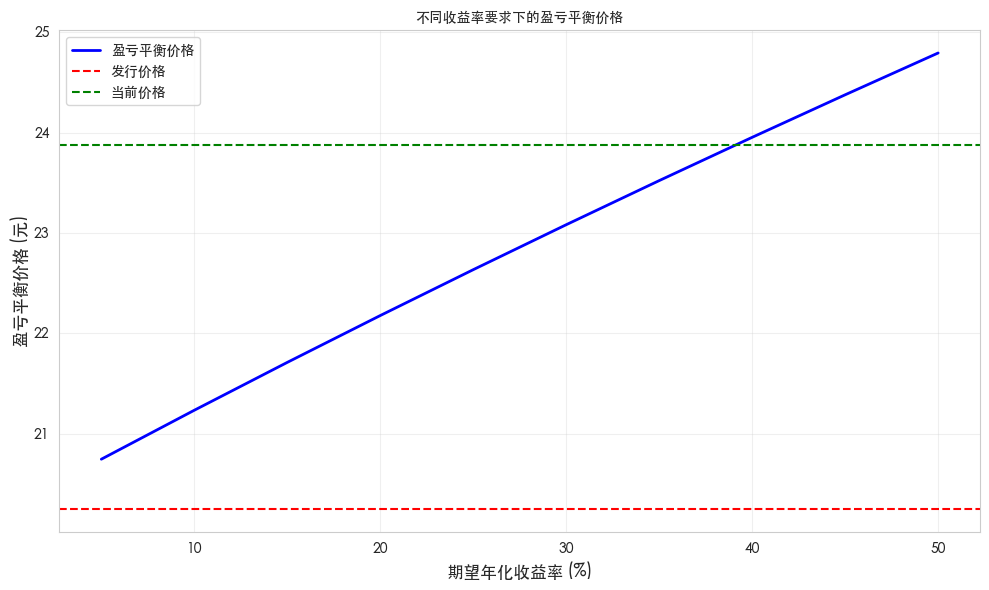


=== 盈亏平衡价格分析 ===
10%年化收益率: 盈亏平衡=21.23元, 距离当前价=11.08%
15%年化收益率: 盈亏平衡=21.71元, 距离当前价=9.09%
20%年化收益率: 盈亏平衡=22.18元, 距离当前价=7.13%
25%年化收益率: 盈亏平衡=22.63元, 距离当前价=5.21%
30%年化收益率: 盈亏平衡=23.08元, 距离当前价=3.34%


In [4]:
# 不同期望收益率下的盈亏平衡价格
target_returns = np.linspace(0.05, 0.50, 10)  # 5%到50%的年化收益率
break_even_prices = [analyzer.calculate_break_even_price(r) for r in target_returns]

# 绘制敏感性曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(target_returns * 100, break_even_prices, 'b-', linewidth=2, label='盈亏平衡价格')
ax.axhline(y=project_params['issue_price'], color='r', linestyle='--', label='发行价格')
ax.axhline(y=project_params['current_price'], color='g', linestyle='--', label='当前价格')

ax.set_xlabel('期望年化收益率 (%)', fontsize=12, fontproperties=font_prop)
ax.set_ylabel('盈亏平衡价格 (元)', fontsize=12, fontproperties=font_prop)
ax.set_title('不同收益率要求下的盈亏平衡价格', fontsize=14, fontweight='bold', fontproperties=font_prop)
ax.legend(prop=font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印关键数据点
print('\n=== 盈亏平衡价格分析 ===')
for ret in [0.10, 0.15, 0.20, 0.25, 0.30]:
    be_price = analyzer.calculate_break_even_price(ret)
    distance = (analyzer.current_price - be_price) / analyzer.current_price
    print(f"{ret*100:.0f}%年化收益率: 盈亏平衡={be_price:.2f}元, 距离当前价={distance*100:.2f}%")

## 3. 锁定期敏感性分析

In [5]:
# 不同锁定期下的盈亏平衡分析
lockup_periods = [6, 9, 12, 18, 24, 36]  # 不同的锁定期（月）
target_return = 0.20  # 20%年化收益率

lockup_analysis = []
for period in lockup_periods:
    # 修改分析器的锁定期
    analyzer.lockup_period = period
    
    # 计算盈亏平衡价格（20%年化收益率）
    be_price = analyzer.calculate_break_even_price(target_return)
    
    # 计算需要的涨幅
    required_increase = (be_price - analyzer.issue_price) / analyzer.issue_price
    
    lockup_analysis.append({
        'lockup_period': period,
        'break_even_price': be_price,
        'required_increase': required_increase
    })

df_lockup = pd.DataFrame(lockup_analysis)

print('=== 锁定期敏感性分析 ===')
print(f"{'锁定期(月)':<12} {'盈亏平衡价':<15} {'需要涨幅':<12}")
print('-'*40)
for _, row in df_lockup.iterrows():
    print(f"{int(row['lockup_period']):<8} {row['break_even_price']:>10.2f}元     {row['required_increase']*100:>8.2f}%")

=== 锁定期敏感性分析 ===
锁定期(月)       盈亏平衡价           需要涨幅        
----------------------------------------
6             22.18元         9.54%
9             23.21元        14.65%
12            24.29元        20.00%
18            26.61元        31.45%
24            29.15元        44.00%
36            34.98元        72.80%


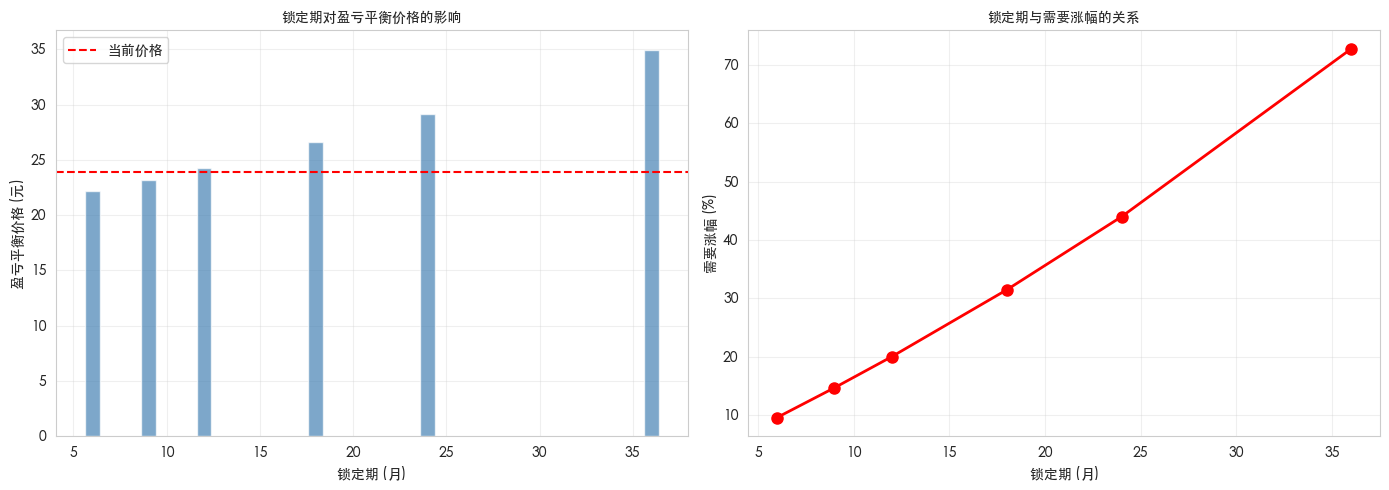

In [6]:
# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(df_lockup['lockup_period'], df_lockup['break_even_price'], color='steelblue', alpha=0.7)
ax1.axhline(y=project_params['current_price'], color='r', linestyle='--', label='当前价格')
ax1.set_xlabel('锁定期 (月)', fontproperties=font_prop)
ax1.set_ylabel('盈亏平衡价格 (元)', fontproperties=font_prop)
ax1.set_title('锁定期对盈亏平衡价格的影响', fontproperties=font_prop)
ax1.legend(prop=font_prop)
for label in ax1.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)
ax1.grid(True, alpha=0.3)

ax2.plot(df_lockup['lockup_period'], df_lockup['required_increase']*100, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('锁定期 (月)', fontproperties=font_prop)
ax2.set_ylabel('需要涨幅 (%)', fontproperties=font_prop)
ax2.set_title('锁定期与需要涨幅的关系', fontproperties=font_prop)
for label in ax2.get_xticklabels():
    label.set_fontproperties(font_prop)
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# 参数敏感性分析（龙卷风图）
# 分析各参数对收益率的影响

# 基准参数
base_params = {
    'issue_price': 20.0,
    'current_price': 18.5,
    'lockup_period': 12,
    'volatility': 0.35,
    'drift': 0.08
}

# 计算基准收益率
def calculate_return_params(params):
    period_years = params['lockup_period'] / 12
    vol_period = params['volatility'] * np.sqrt(period_years)
    drift_period = params['drift'] * period_years
    required_return = (params['current_price'] - params['issue_price']) / params['issue_price']
    z_score = (drift_period - required_return) / vol_period
    from scipy.stats import norm
    profit_prob = 1 - norm.cdf(-z_score)
    return profit_prob

base_return = calculate_return_params(base_params)

# 参数变化分析
param_changes = []
changes = [-0.2, -0.1, 0.1, 0.2]  # ±10%, ±20%

# 1. 发行价格敏感性
for change in changes:
    params = base_params.copy()
    params['issue_price'] = base_params['issue_price'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'发行价 ({int(change*100)}%)', 'impact_percent': impact})

# 2. 当前价格敏感性
for change in changes:
    params = base_params.copy()
    params['current_price'] = base_params['current_price'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'当前价 ({int(change*100)}%)', 'impact_percent': impact})

# 3. 锁定期敏感性
for change in changes:
    params = base_params.copy()
    params['lockup_period'] = base_params['lockup_period'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'锁定期 ({int(change*100)}%)', 'impact_percent': impact})

# 4. 波动率敏感性
for change in changes:
    params = base_params.copy()
    params['volatility'] = base_params['volatility'] * (1 + change)
    new_return = calculate_return_params(params)
    impact = (new_return - base_return) * 100
    param_changes.append({'parameter': f'波动率 ({int(change*100)}%)', 'impact_percent': impact})

# 按影响程度排序
df_tornado = pd.DataFrame(param_changes).sort_values('impact_percent')

print('\n=== 参数敏感性排序（龙卷风图）===')
print(f"{'参数':<25} {'对盈利概率的影响':<15}")
print('-'*40)
for _, row in df_tornado.iterrows():
    print(f"{row['parameter']:<20} {row['impact_percent']:>8.2f}%")


=== 参数敏感性排序（龙卷风图）===
参数                        对盈利概率的影响       
----------------------------------------
发行价 (-20%)             -25.73%
当前价 (20%)              -20.52%
发行价 (-10%)             -11.18%
当前价 (10%)              -10.02%
波动率 (20%)               -2.71%
波动率 (10%)               -1.47%
锁定期 (-10%)              -0.01%
锁定期 (-20%)               0.04%
锁定期 (10%)                0.04%
锁定期 (20%)                0.11%
波动率 (-10%)               1.76%
波动率 (-20%)               3.90%
发行价 (10%)                8.17%
当前价 (-10%)               8.92%
发行价 (20%)               14.04%
当前价 (-20%)              16.33%


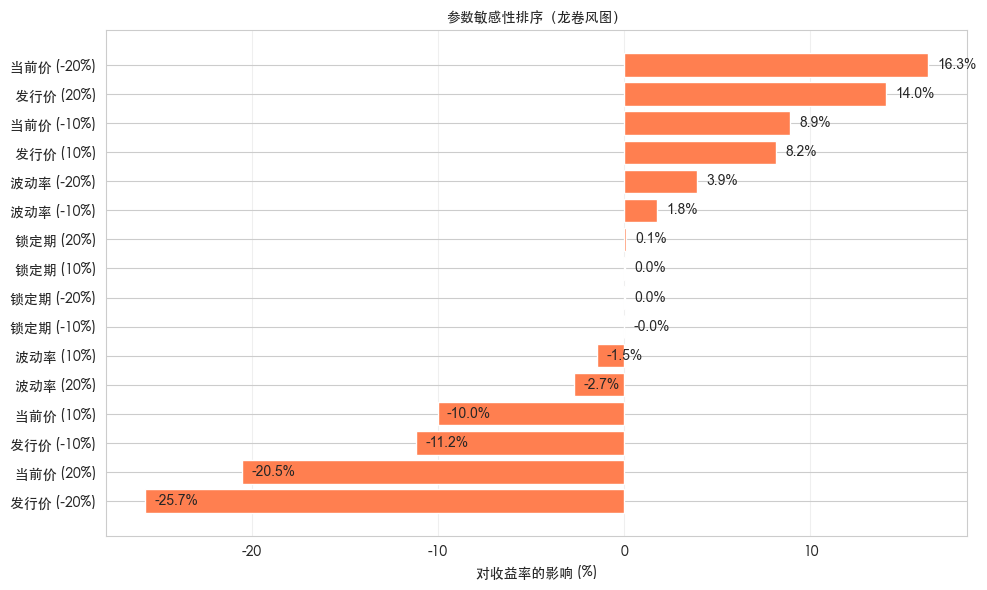

In [8]:
# 绘制龙卷风图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(df_tornado['parameter'], df_tornado['impact_percent'], color='coral')
ax.set_xlabel('对收益率的影响 (%)', fontproperties=font_prop)
ax.set_title('参数敏感性排序（龙卷风图）', fontsize=14, fontweight='bold', fontproperties=font_prop)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_prop)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_prop)
ax.grid(True, axis='x', alpha=0.3)

# 添加数值标签
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', ha='left', va='center')

plt.tight_layout()
plt.show()

## 4. 敏感性分析结论

In [9]:
print('\n' + '='*50)
print('敏感性分析结论')
print('='*50)
print(f"\n1. 当前价格较发行价: {(analyzer.current_price/analyzer.issue_price - 1)*100:.2f}%")
print(f"\n2. 20%年化收益率要求下的盈亏平衡价: {analyzer.calculate_break_even_price(0.20):.2f}元")
print(f"\n3. 当前价距离盈亏平衡价: {(analyzer.current_price - analyzer.calculate_break_even_price(0.20))/analyzer.current_price*100:.2f}%")
print(f"\n4. 最敏感的参数是: {df_tornado.iloc[-1]['parameter']}")


敏感性分析结论

1. 当前价格较发行价: 17.95%

2. 20%年化收益率要求下的盈亏平衡价: 34.98元

3. 当前价距离盈亏平衡价: -46.50%

4. 最敏感的参数是: 当前价 (-20%)
